In [4]:
from qrwqkd import EntangledWalkersQKD
import numpy as np

In [5]:
coin_params = {"a": 0.85, "phi": np.pi / 4, "theta": 0.635, "lam": 0}
protocol = EntangledWalkersQKD(2, coin_params=coin_params)
print(protocol)

2-step entangled walkers QKD protocol
coin parameters:
-----------
Initial coin state: 0.85|00> + (0.37249161064378356+0.37249161064378356j)|11>
Coin-flip operator U(θ,λ) = U(0.635, 0) = 
 [[ 0.95001887+0.j -0.31219249-0.j]
 [ 0.31219249+0.j  0.95001887+0.j]]


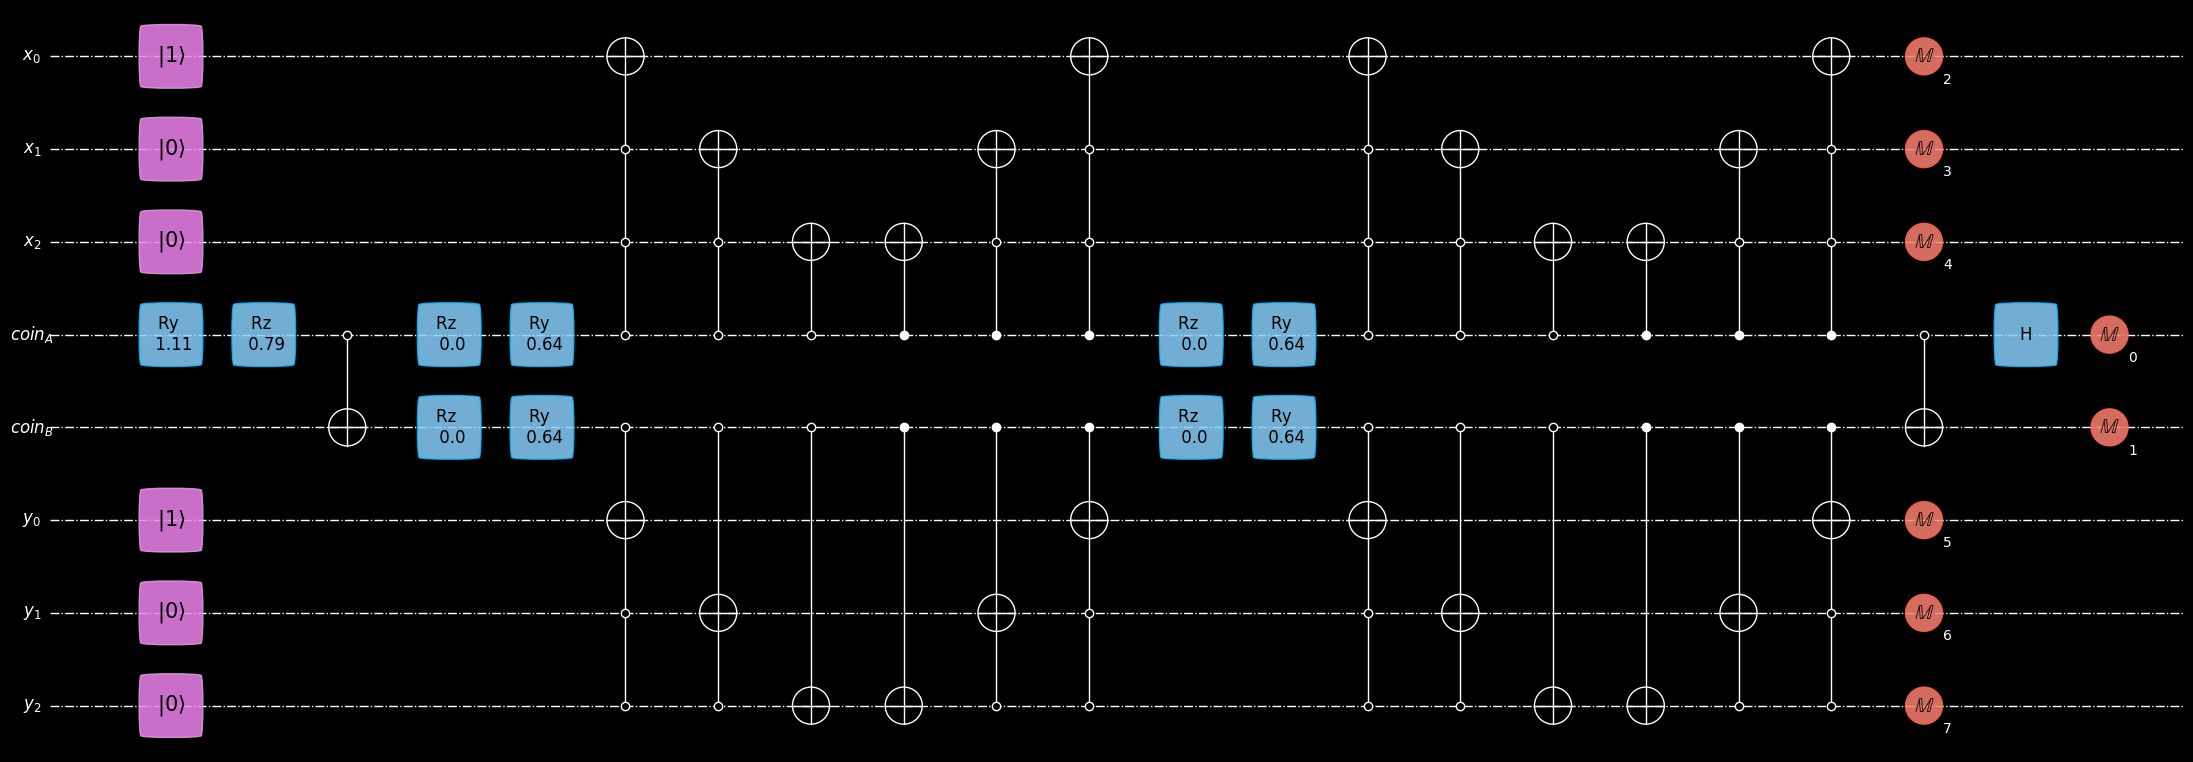

In [6]:
from geqo.simulators import ensembleSimulatorCuPy
from geqo.visualization import plot_mpl

circuit, params = protocol.quantum_circuit()  # load the quantum circuit of the protocol
sim = ensembleSimulatorCuPy(8, 8)
sim.values = params
plot_mpl(circuit, backend=sim, style="geqo_dark")

In [7]:
# simulate the circuit and calculate the probability distributions
stats = protocol.evaluate_circuit(circuit, params, normalize=True)

for outcome, ensemble in stats.items():
    print(f"BSM outcome {outcome}: \n-------------\nprobability = {ensemble[0]}")
    print("joint position distribution (Alice, Bob):")
    for key, item in ensemble[1].items():
        print(f"{key}, prob = {item}")
    print("-" * 30 + "\n" + "-" * 30)

BSM outcome 00: 
-------------
probability = 0.3944386616615785
joint position distribution (Alice, Bob):
(-2, -2), prob = 0.667934419903556
(-2, 0), prob = 0.0035974624964609106
(0, -2), prob = 0.0035974624964609098
(0, 0), prob = 0.01966659694006826
(0, 2), prob = 0.0035974624964609098
(2, 0), prob = 0.0035974624964609106
(2, 2), prob = 0.298009133170532
------------------------------
------------------------------
BSM outcome 01: 
-------------
probability = 0.10918191157112318
joint position distribution (Alice, Bob):
(-2, 0), prob = 0.2605811842538186
(-2, 2), prob = 0.12034958896971477
(0, -2), prob = 0.26058118425381865
(0, 0), prob = 0.005613910645729801
(0, 2), prob = 0.11626227145360166
(2, -2), prob = 0.12034958896971477
(2, 0), prob = 0.11626227145360166
------------------------------
------------------------------
BSM outcome 10: 
-------------
probability = 0.3878104526918651
joint position distribution (Alice, Bob):
(-2, -2), prob = 0.679350329099543
(-2, 0), prob = 0.00